# Awning AI Prompt Sandbox

Test and score prompt variants against 30 synthetic weather scenarios on three weighted objectives:
- **Protection** (weight 0.5) — retract when wind/rain is dangerous
- **Solar Shielding** (weight 0.3) — deploy when hot/sunny/safe
- **Token Efficiency** (weight 0.2) — lower token usage is better

### Workflow
1. Edit **Section 1** to pick a prompt variant, model, and weights
2. Run **Section 2** to execute all scenarios against all variants in `prompt_variants/`
3. Review results in **Sections 3–5**
4. Use **Section 6** to drill into any specific scenario report

## Section 0 — Setup

In [1]:
import sys
import os
from pathlib import Path

# Add project root to path so app.* modules are importable
PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Load .env for ANTHROPIC_API_KEY
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

from scenarios import SCENARIOS, SCENARIOS_BY_NAME
from sandbox_runner import run_scenario
from scoring import score_results, summary_by_variant
from app.config import AIConfig

print(f"Project root: {PROJECT_ROOT}")
print(f"Scenarios loaded: {len(SCENARIOS)}")
api_key_set = bool(os.environ.get("ANTHROPIC_API_KEY", "").strip())
print(f"ANTHROPIC_API_KEY set: {api_key_set}")

Project root: /Users/mcdomx/Library/Mobile Documents/com~apple~CloudDocs/myProjects/home_automation/awning_protector
Scenarios loaded: 30
ANTHROPIC_API_KEY set: True


/Users/mcdomx/.local/share/virtualenvs/awning_protector-3b7VvvC5/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Section 1 — Configuration

**Edit this cell between runs.** Drop new `.md.j2` files into `prompt_variants/` to add more variants.

In [2]:
# ── Model ──────────────────────────────────────────────────────────────────
CLAUDE_MODEL = os.environ.get("CLAUDE_MODEL", "claude-haiku-4-5")

# ── AI config (no file I/O — explicit values for reproducible runs) ────────
AI_CFG = AIConfig(
    ai_enabled=True,
    current_wind_threshold_mph=3.0,
    forecasted_wind_threshold_mph=8.0,
    earliest_auto_deployment="8AM",
    latest_auto_deployment="7PM",
    forecast_outlook_hours=2,
    max_deployment_seconds=5,
    min_deployment_seconds=2,
    min_deployment_temp_f=65.0,
    min_eval_interval_seconds=300,
)

# ── Scoring weights (must be positive; need not sum to 1) ──────────────────
WEIGHTS = {
    "protection":       0.5,
    "solar_shielding":  0.3,
    "token_efficiency": 0.2,
}

# ── Prompt variants to test ────────────────────────────────────────────────
# Scans all .md.j2 files in prompt_variants/. Add more files there.
VARIANTS = sorted(Path("prompt_variants").glob("*.md.j2"))

print(f"Model: {CLAUDE_MODEL}")
print(f"Variants to test: {[v.name for v in VARIANTS]}")
print(f"Weights: {WEIGHTS}")

Model: claude-haiku-4-5
Variants to test: ['baseline.md.j2']
Weights: {'protection': 0.5, 'solar_shielding': 0.3, 'token_efficiency': 0.2}


## Section 2 — Run All Scenarios × Variants

Each API call is independent — safe to re-run a single cell if a scenario fails.

In [3]:
import time

all_results = []

for variant_path in VARIANTS:
    print(f"\n{'='*60}")
    print(f"Variant: {variant_path.name}")
    print(f"{'='*60}")
    for scenario in SCENARIOS:
        r = run_scenario(scenario, variant_path, AI_CFG, CLAUDE_MODEL)
        all_results.append(r)
        status = "OK" if not r.error else f"ERROR: {r.error[:60]}"
        correct_marker = "✓" if r.action_taken == scenario["expected_action"] else "✗"
        print(
            f"  {correct_marker} {scenario['name']:<40s}"
            f" expected={scenario['expected_action']:<8s}"
            f" got={r.action_taken:<8s}"
            f" tokens={r.total_tokens:>5d}  {status}"
        )

print(f"\nTotal runs: {len(all_results)}")


Variant: baseline.md.j2
  ✓ heavy_rain_deployed                      expected=retract  got=retract  tokens=11919  OK
  ✓ high_wind_deployed                       expected=retract  got=retract  tokens=12153  OK
  ✓ forecast_rain_1h                         expected=retract  got=retract  tokens=11509  OK
  ✓ forecast_high_wind_2h                    expected=retract  got=retract  tokens=12292  OK
  ✓ after_hours_deployed                     expected=retract  got=retract  tokens=12228  OK
  ✓ light_mist_deployed                      expected=retract  got=retract  tokens=11982  OK
  ✓ rising_wind_trend                        expected=retract  got=retract  tokens=12196  OK
  ✓ forecast_rain_and_wind                   expected=retract  got=retract  tokens=11502  OK
  ✓ peak_solar_calm                          expected=deploy   got=deploy   tokens=16509  OK
  ✓ hot_sunny_morning                        expected=deploy   got=deploy   tokens=16646  OK
  ✓ summer_afternoon                         

In [11]:
print(f"Average Total Tokens: {sum([x.total_tokens for x in all_results])/ len(all_results)}")

Average Total Tokens: 13135.233333333334


## Section 3 — Raw Results Table

In [12]:
raw_rows = []
for r in all_results:
    sc = SCENARIOS_BY_NAME[r.scenario_name]
    raw_rows.append({
        "variant":       r.prompt_variant,
        "scenario":      r.scenario_name,
        "objectives":    ", ".join(sc["objectives"]),
        "expected":      sc["expected_action"],
        "actual":        r.action_taken,
        "correct":       r.action_taken == sc["expected_action"],
        "input_tokens":  r.input_tokens,
        "output_tokens": r.output_tokens,
        "total_tokens":  r.total_tokens,
        "tool_calls":    len(r.tool_calls),
        "error":         r.error or "",
    })

raw_df = pd.DataFrame(raw_rows)


def _color_correct(val):
    if val is True:
        return "background-color: #d4edda; color: #155724"
    if val is False:
        return "background-color: #f8d7da; color: #721c24"
    return ""


display(
    raw_df.style
    .applymap(_color_correct, subset=["correct"])
    .set_caption("Raw Results — green = correct action, red = wrong action")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold")]}])
)

/var/folders/kx/q9fjwy3d6dq9w88pvs57tv6w0000gn/T/ipykernel_65594/1800188727.py:30: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  raw_df.style


,variant,scenario,objectives,expected,actual,correct,input_tokens,output_tokens,total_tokens,tool_calls,error
0,baseline.md.j2,heavy_rain_deployed,protection,retract,retract,True,10651,1268,11919,7,
1,baseline.md.j2,high_wind_deployed,protection,retract,retract,True,10728,1425,12153,7,
2,baseline.md.j2,forecast_rain_1h,protection,retract,retract,True,10437,1072,11509,7,
3,baseline.md.j2,forecast_high_wind_2h,protection,retract,retract,True,10814,1478,12292,7,
4,baseline.md.j2,after_hours_deployed,protection,retract,retract,True,10782,1446,12228,7,
5,baseline.md.j2,light_mist_deployed,protection,retract,retract,True,10692,1290,11982,7,
6,baseline.md.j2,rising_wind_trend,protection,retract,retract,True,10765,1431,12196,7,
7,baseline.md.j2,forecast_rain_and_wind,protection,retract,retract,True,10424,1078,11502,7,
8,baseline.md.j2,peak_solar_calm,solar_shielding,deploy,deploy,True,15029,1480,16509,7,
9,baseline.md.j2,hot_sunny_morning,solar_shielding,deploy,deploy,True,15129,1517,16646,7,


## Section 4 — Score Table

In [13]:
scores = score_results(all_results, SCENARIOS_BY_NAME, WEIGHTS)

score_rows = [{
    "variant":    s.prompt_variant,
    "scenario":   s.scenario_name,
    "correct":    s.correct,
    "protection": s.protection_score,
    "solar":      s.solar_score,
    "token":      s.token_score,
    "composite":  s.composite,
} for s in scores]

score_df = pd.DataFrame(score_rows)

print("=== Per-scenario scores ===")
display(
    score_df.style
    .applymap(_color_correct, subset=["correct"])
    .background_gradient(subset=["composite"], cmap="RdYlGn", vmin=0, vmax=1)
    .format({"protection": "{:.2f}", "solar": "{:.2f}",
             "token": "{:.3f}", "composite": "{:.3f}"}, na_rep="-")
)

print("\n=== Summary by variant ===")
summary = summary_by_variant(scores)
summary_df = pd.DataFrame(summary).T.sort_values("composite", ascending=False)
display(
    summary_df.style
    .background_gradient(subset=["composite", "accuracy"], cmap="RdYlGn", vmin=0, vmax=1)
    .format("{:.3f}", na_rep="-")
    .set_caption(f"Mean scores per variant  |  weights: {WEIGHTS}")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold")]}])
)

=== Per-scenario scores ===


/var/folders/kx/q9fjwy3d6dq9w88pvs57tv6w0000gn/T/ipykernel_65594/2516732384.py:17: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  score_df.style


,variant,scenario,correct,protection,solar,token,composite
0,baseline.md.j2,heavy_rain_deployed,True,1.00,-,0.000,0.714
1,baseline.md.j2,high_wind_deployed,True,1.00,-,0.000,0.714
2,baseline.md.j2,forecast_rain_1h,True,1.00,-,0.000,0.714
3,baseline.md.j2,forecast_high_wind_2h,True,1.00,-,0.000,0.714
4,baseline.md.j2,after_hours_deployed,True,1.00,-,0.000,0.714
5,baseline.md.j2,light_mist_deployed,True,1.00,-,0.000,0.714
6,baseline.md.j2,rising_wind_trend,True,1.00,-,0.000,0.714
7,baseline.md.j2,forecast_rain_and_wind,True,1.00,-,0.000,0.714
8,baseline.md.j2,peak_solar_calm,True,-,1.00,0.000,0.600
9,baseline.md.j2,hot_sunny_morning,True,-,1.00,0.000,0.600



=== Summary by variant ===


,composite,accuracy,protection,solar,token_efficiency
baseline.md.j2,0.541,0.867,0.889,0.889,0.000


## Section 5 — Visualizations

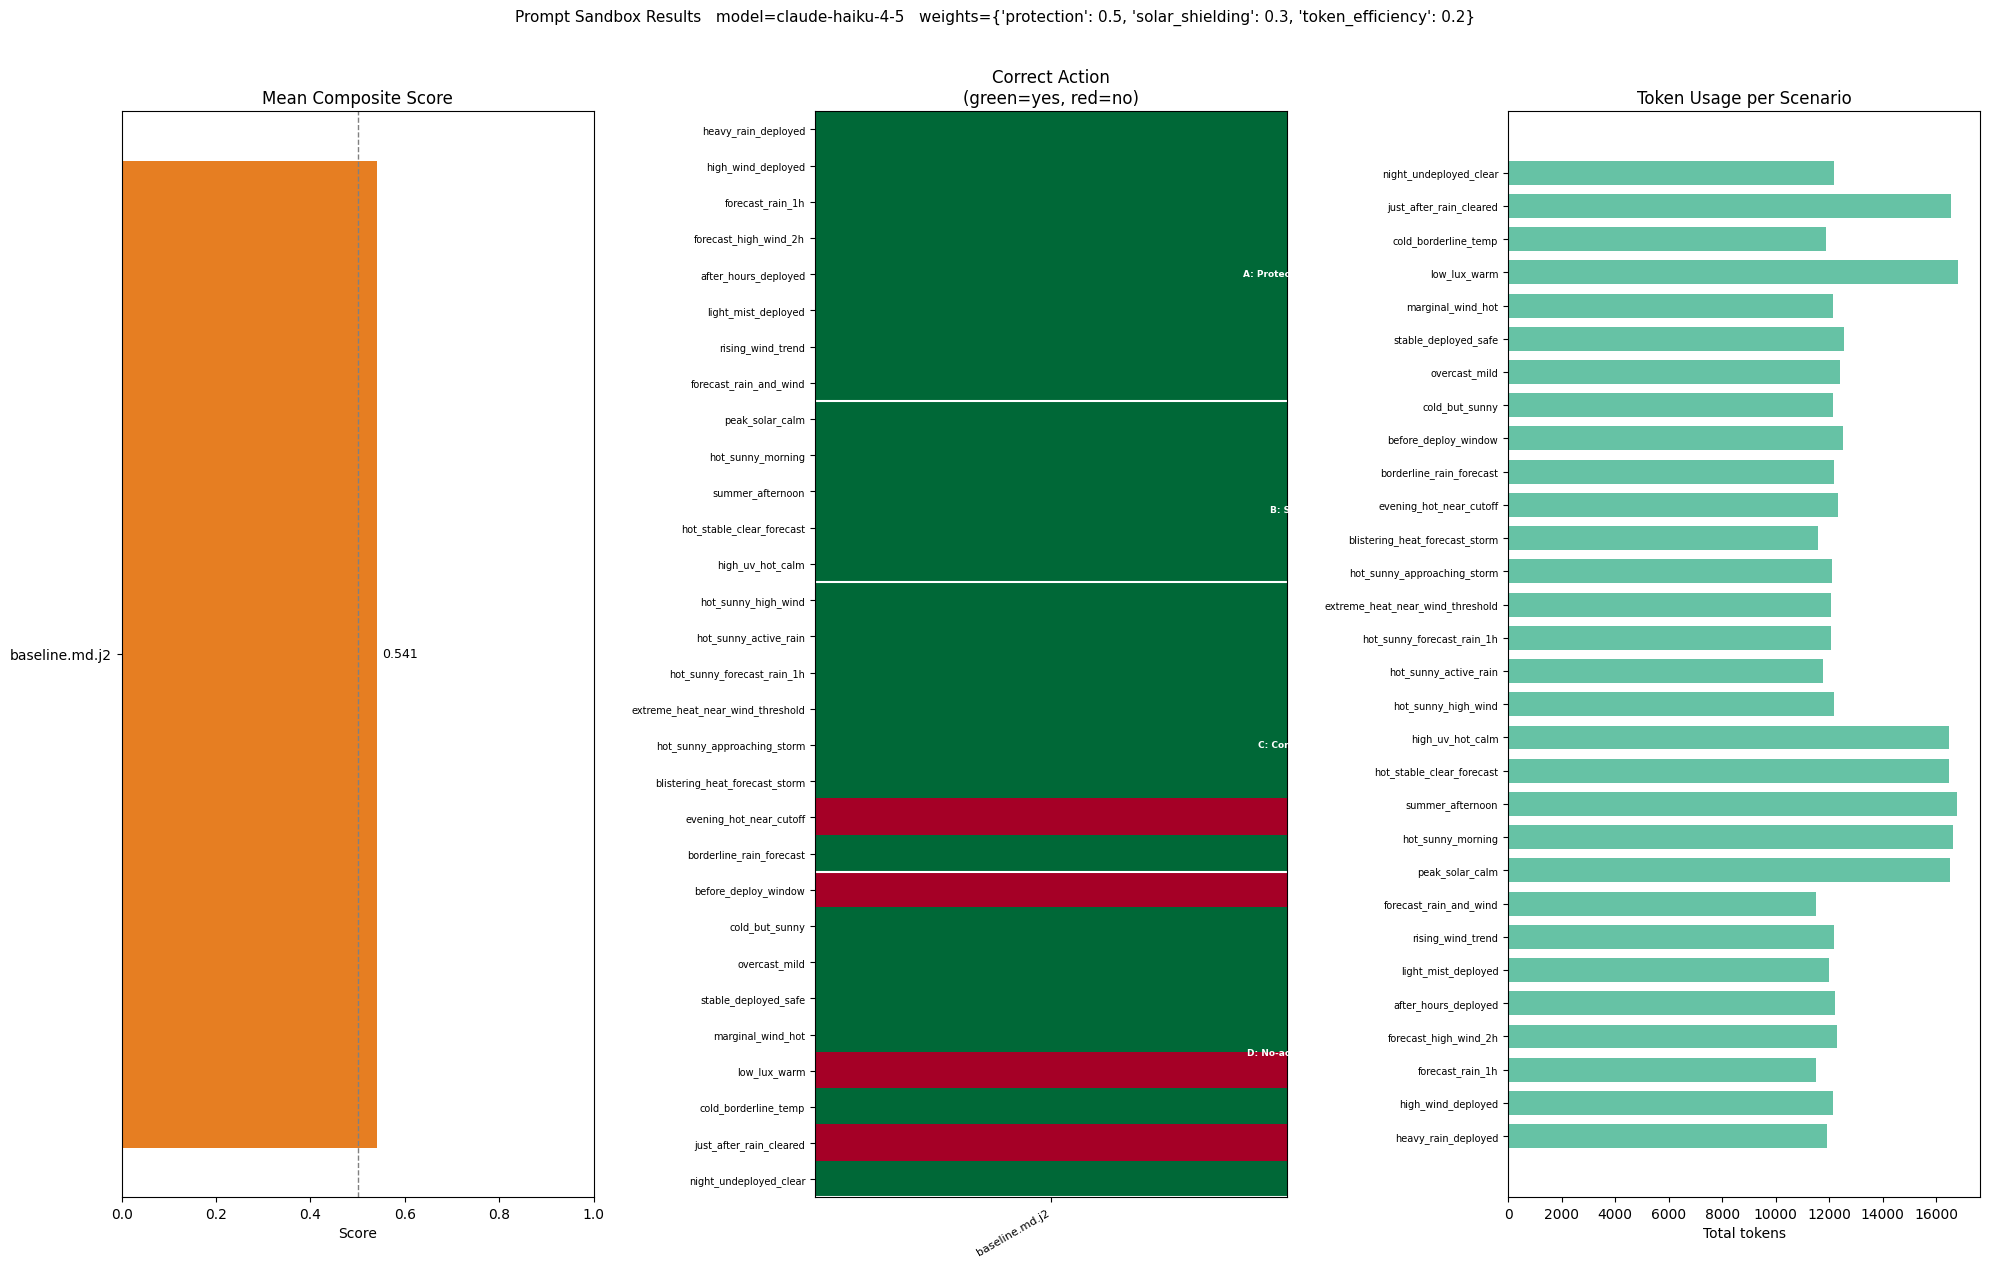

Saved: results_latest.png


In [14]:
variant_names = [v.name for v in VARIANTS]
scenario_names = [s["name"] for s in SCENARIOS]

fig, axes = plt.subplots(1, 3, figsize=(20, max(6, len(scenario_names) * 0.35 + 2)))
fig.suptitle(f"Prompt Sandbox Results   model={CLAUDE_MODEL}   weights={WEIGHTS}",
             fontsize=11, y=1.01)

# ── Chart 1: mean composite score per variant ──────────────────────────────
ax1 = axes[0]
comp_means = summary_df["composite"].values
colors = ["#2ecc71" if v >= 0.7 else "#e67e22" if v >= 0.5 else "#e74c3c"
          for v in comp_means]
bars = ax1.barh(summary_df.index, comp_means, color=colors)
ax1.set_xlim(0, 1)
ax1.axvline(0.5, color="gray", linestyle="--", linewidth=1)
ax1.set_title("Mean Composite Score")
ax1.set_xlabel("Score")
for bar, val in zip(bars, comp_means):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center", fontsize=9)

# ── Chart 2: correct/incorrect heatmap ────────────────────────────────────
ax2 = axes[1]
pivot = raw_df.pivot_table(
    index="scenario", columns="variant", values="correct", aggfunc="first"
).reindex(index=scenario_names)
pivot_vals = pivot.values.astype(float)

im = ax2.imshow(pivot_vals, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax2.set_xticks(range(len(pivot.columns)))
ax2.set_xticklabels(pivot.columns, rotation=30, ha="right", fontsize=8)
ax2.set_yticks(range(len(pivot.index)))
ax2.set_yticklabels(pivot.index, fontsize=7)
ax2.set_title("Correct Action\n(green=yes, red=no)")

# Annotate group boundaries
group_boundaries = [8, 13, 21]  # after protection, solar, conflict groups
group_labels = ["A: Protection", "B: Solar", "C: Conflict", "D: No-action"]
prev = 0
for gb, label in zip(group_boundaries + [len(scenario_names)], group_labels):
    mid = (prev + gb) / 2
    ax2.axhline(gb - 0.5, color="white", linewidth=1.5)
    ax2.text(len(pivot.columns) - 0.45, mid, label,
             va="center", ha="right", fontsize=6.5, color="white",
             fontweight="bold")
    prev = gb

# ── Chart 3: token usage per scenario per variant ─────────────────────────
ax3 = axes[2]
token_pivot = raw_df.pivot_table(
    index="scenario", columns="variant", values="total_tokens", aggfunc="first"
).reindex(index=scenario_names)

n_variants = len(token_pivot.columns)
y_pos = np.arange(len(token_pivot.index))
bar_height = 0.8 / max(n_variants, 1)
palette = plt.cm.Set2.colors

for i, col in enumerate(token_pivot.columns):
    offset = (i - n_variants / 2 + 0.5) * bar_height
    ax3.barh(y_pos + offset, token_pivot[col].fillna(0),
             height=bar_height * 0.9,
             label=col, color=palette[i % len(palette)])

ax3.set_yticks(y_pos)
ax3.set_yticklabels(token_pivot.index, fontsize=7)
ax3.set_title("Token Usage per Scenario")
ax3.set_xlabel("Total tokens")
if n_variants > 1:
    ax3.legend(fontsize=7, loc="lower right")

plt.tight_layout()
plt.savefig("results_latest.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: results_latest.png")

## Section 6 — Drill-Down

Set `VIEW_SCENARIO` and `VIEW_VARIANT` to inspect the full Claude report for any run.

In [15]:
VIEW_SCENARIO = "heavy_rain_deployed"
VIEW_VARIANT  = "baseline.md.j2"

matches = [
    r for r in all_results
    if r.scenario_name == VIEW_SCENARIO and r.prompt_variant == VIEW_VARIANT
]

if not matches:
    print(f"No result found for scenario='{VIEW_SCENARIO}' variant='{VIEW_VARIANT}'")
    print(f"Available scenarios: {[r.scenario_name for r in all_results[:5]]}...")
else:
    r = matches[0]
    sc = SCENARIOS_BY_NAME[r.scenario_name]
    print(f"Scenario:   {r.scenario_name}")
    print(f"Variant:    {r.prompt_variant}")
    print(f"Expected:   {sc['expected_action']}")
    print(f"Actual:     {r.action_taken}  {'✓ CORRECT' if r.action_taken == sc['expected_action'] else '✗ WRONG'}")
    print(f"Tokens:     input={r.input_tokens}  output={r.output_tokens}  total={r.total_tokens}")
    print(f"Tool calls: {r.tool_calls}")
    if r.error:
        print(f"Error:      {r.error}")
    print("\n" + "─" * 70)
    print(r.report_text)

Scenario:   heavy_rain_deployed
Variant:    baseline.md.j2
Expected:   retract
Actual:     retract  ✓ CORRECT
Tokens:     input=10651  output=1268  total=11919
Tool calls: ['get_weather', 'get_wind', 'get_weather_history', 'get_forecast', 'get_awning_status', 'retract_awning', 'log_awning_action']

──────────────────────────────────────────────────────────────────────
AWNING CONTROL REPORT
---------------------
Timestamp:            2026-06-06T14:00:00Z

Awning Status Before: deployed
Action Taken:         retracted

Current Weather Assessment: Temperature is 71.6°F (above 65°F minimum), but active precipitation of 2.5mm is present. This is a critical safety violation of the primary objective. The awning cannot remain deployed in any precipitation.

Current Wind Assessment: Wind speed is 2.24 MPH, which is below the 3.0 MPH threshold for current conditions. Wind conditions are safe, but precipitation takes priority.

Recent History Assessment: The past hour shows consistent precipitati

## Section 7 — Run a Single Scenario (quick iteration)

Use this to test a specific scenario against a specific prompt without re-running everything.

In [ ]:
SINGLE_SCENARIO = "peak_solar_calm"
SINGLE_VARIANT  = Path("prompt_variants/baseline.md.j2")

sc = SCENARIOS_BY_NAME[SINGLE_SCENARIO]
r = run_scenario(sc, SINGLE_VARIANT, AI_CFG, CLAUDE_MODEL)

correct = r.action_taken == sc["expected_action"]
print(f"Expected: {sc['expected_action']}   Got: {r.action_taken}   {'✓' if correct else '✗'}")
print(f"Tokens: {r.total_tokens}   Tools: {r.tool_calls}")
if r.error:
    print(f"Error: {r.error}")
print("\n" + "─" * 70)
print(r.report_text)